We first want to split our data up into training, validation, and test data.

In [ ]:
import pandas as pd
import os

all_dfs = []

csv_base_path = '/content/'

for year in range(2021, 2024):
    file_name = f'NBA_Momentum_Cleaned_{year}.csv'
    file_path = os.path.join(csv_base_path, file_name)

    if os.path.exists(file_path):
        print(f'Loading {file_name}...')
        df_year = pd.read_csv(file_path)
        all_dfs.append(df_year)
    else:
        print(f'Warning: {file_name} not found. Skipping.')

if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f'Successfully combined {len(all_dfs)} datasets. Total rows: {len(combined_df)}')
    display(combined_df.head())
else:
    print('No CSV files were loaded.')

Loading NBA_Momentum_Cleaned_2021.csv...
Loading NBA_Momentum_Cleaned_2022.csv...
Loading NBA_Momentum_Cleaned_2023.csv...
Successfully combined 3 datasets. Total rows: 624925


,PLAYER_ID,GAME_ID,QUARTER,seconds_remaining,SHOT_DISTANCE,LOC_X,LOC_Y,fg_pct_last_5,fg_pct_last_3,fg_pct_last_10,time_since_last_shot,score_diff,is_home_team,SHOT_MADE
0,203114,22000000,1,706,26,-1.43,7.995,0.0,0.0,0.0,0.0,0.0,0,False
1,1629130,22000000,1,703,26,-0.10,8.385,0.0,0.0,0.0,0.0,0.0,1,True
2,203076,22000000,1,700,14,0.91,6.945,0.0,0.0,0.0,0.0,0.0,1,False
3,1629029,22000000,1,697,3,-0.09,6.085,0.0,0.0,0.0,0.0,0.0,0,False
4,202684,22000000,1,693,9,0.13,6.755,0.0,0.0,0.0,0.0,0.0,1,True


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


df = combined_df.copy()

n = len(df)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Total dataset size: {len(df)}")
print(f"Training set:   0 to {train_end-1} (Size: {len(train_df)}, Percentage: {len(train_df)/n:.2%})")
print(f"Validation set: {train_end} to {val_end-1} (Size: {len(val_df)}, Percentage: {len(val_df)/n:.2%})")
print(f"Test set:       {val_end} to {n-1} (Size: {len(test_df)}, Percentage: {len(test_df)/n:.2%})")

Total dataset size: 624925
Training set:   0 to 374954 (Size: 374955, Percentage: 60.00%)
Validation set: 374955 to 499939 (Size: 124985, Percentage: 20.00%)
Test set:       499940 to 624924 (Size: 124985, Percentage: 20.00%)


Now we want to apply our data to train a **logistic regression model** that predicts shot accuracy based on our features.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

features = ['QUARTER', 'seconds_remaining', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
            'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
            'time_since_last_shot', 'score_diff', 'is_home_team']
target = 'SHOT_MADE'

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
val_acc = accuracy_score(y_val, model.predict(X_val_scaled))
test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

print(f"Training Accuracy:   {train_acc:.4%}")
print(f"Validation Accuracy: {val_acc:.4%}")
print(f"Test Accuracy:       {test_acc:.4%}")

Training Accuracy:   59.3466%
Validation Accuracy: 59.6520%
Test Accuracy:       59.4015%


This accuracy percentage seems quite low. Maybe this is because of our feature scaling? Let's try it without feature scaling.

In [ ]:

features = ['QUARTER', 'seconds_remaining', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
            'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
            'time_since_last_shot', 'score_diff', 'is_home_team']
target = 'SHOT_MADE'

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
val_acc = accuracy_score(y_val, model.predict(X_val))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Training Accuracy:   {train_acc:.4%}")
print(f"Validation Accuracy: {val_acc:.4%}")
print(f"Test Accuracy:       {test_acc:.4%}")

Training Accuracy:   59.3418%
Validation Accuracy: 59.6608%
Test Accuracy:       59.4111%


This didn't change much, so the low accuracy score might just be due to the logistic regression model's inability to capture the relationships between features and output variable.

Now we want to test a **SVM classifier** model.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

features = ['QUARTER', 'seconds_remaining', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
            'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
            'time_since_last_shot', 'score_diff', 'is_home_team']
target = 'SHOT_MADE'

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=features, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

sample_fraction = 0.1
sample_size = int(len(X_train_scaled_df) * sample_fraction)
np.random.seed(42)
sampled_indices = np.random.choice(len(X_train_scaled_df), sample_size, replace=False)

X_train_sampled_svm = X_train_scaled_df.iloc[sampled_indices]
y_train_sampled_svm = y_train.iloc[sampled_indices]

print(f"Original training data size: {len(X_train_scaled_df)}")
print(f"Subsampled training data size: {len(X_train_sampled_svm)} ({sample_fraction:.0%} of original)")

svm_model = SVC(kernel='linear', C=1.0, random_state=42)
print("Training SVM model with subsampled data... This should be faster.")
svm_model.fit(X_train_sampled_svm, y_train_sampled_svm)

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train_scaled_df))
svm_val_acc = accuracy_score(y_val, svm_model.predict(X_val_scaled_df))
svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test_scaled_df))

print(f"\nSVM Training Accuracy (on full training set):   {svm_train_acc:.4%}")
print(f"SVM Validation Accuracy: {svm_val_acc:.4%}")
print(f"SVM Test Accuracy:       {svm_test_acc:.4%}")

Original training data size: 374955
Subsampled training data size: 37495 (10% of original)
Training SVM model with subsampled data... This should be faster.


KeyboardInterrupt: 

In [ ]:
print(f"\nSVM Training Accuracy:  {svm_train_acc:.4%}")
print(f"SVM Validation Accuracy: {svm_val_acc:.4%}")
print(f"SVM Test Accuracy:       {svm_test_acc:.4%}")


SVM Training Accuracy:  59.5509%
SVM Validation Accuracy: 52.5007%
SVM Test Accuracy:       50.4981%


Now, let's test an **SVM classifier (SVC)** with a reduced set of features.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

features_to_remove = ['fg_pct_last_5', 'fg_pct_last_10', 'fg_pct_last_3',
                      'time_since_last_shot', 'score_diff', 'is_home_team',
                      'seconds_remaining']

original_svm_features = ['QUARTER', 'seconds_remaining', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
            'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
            'time_since_last_shot', 'score_diff', 'is_home_team']

features_reduced_svm = [f for f in original_svm_features if f not in features_to_remove]

target = 'SHOT_MADE'

X_train_reduced_svm, y_train_svm = train_df[features_reduced_svm], train_df[target]
X_val_reduced_svm, y_val_svm = val_df[features_reduced_svm], val_df[target]
X_test_reduced_svm, y_test_svm = test_df[features_reduced_svm], test_df[target]

scaler_svm_reduced = StandardScaler()
X_train_scaled_reduced_svm = scaler_svm_reduced.fit_transform(X_train_reduced_svm)
X_val_scaled_reduced_svm = scaler_svm_reduced.transform(X_val_reduced_svm)
X_test_scaled_reduced_svm = scaler_svm_reduced.transform(X_test_reduced_svm)

X_train_scaled_reduced_df = pd.DataFrame(X_train_scaled_reduced_svm, columns=features_reduced_svm, index=X_train_reduced_svm.index)
X_val_scaled_reduced_df = pd.DataFrame(X_val_scaled_reduced_svm, columns=features_reduced_svm, index=X_val_reduced_svm.index)
X_test_scaled_reduced_df = pd.DataFrame(X_test_scaled_reduced_svm, columns=features_reduced_svm, index=X_test_reduced_svm.index)

sample_fraction = 0.1
sample_size = int(len(X_train_scaled_reduced_df) * sample_fraction)
np.random.seed(42)
sampled_indices = np.random.choice(len(X_train_scaled_reduced_df), sample_size, replace=False)

X_train_sampled_svm_reduced = X_train_scaled_reduced_df.iloc[sampled_indices]
y_train_sampled_svm_reduced = y_train_svm.iloc[sampled_indices]

print(f"Original training data size: {len(X_train_scaled_reduced_df)}")
print(f"Subsampled training data size: {len(X_train_sampled_svm_reduced)} ({sample_fraction:.0%} of original)")

svm_model_reduced = SVC(kernel='linear', C=1.0, random_state=42)
print("Training SVM model with subsampled, reduced data... This should be faster.")
svm_model_reduced.fit(X_train_sampled_svm_reduced, y_train_sampled_svm_reduced)

svm_train_acc_reduced = accuracy_score(y_train_svm, svm_model_reduced.predict(X_train_scaled_reduced_df))
svm_val_acc_reduced = accuracy_score(y_val_svm, svm_model_reduced.predict(X_val_scaled_reduced_df))
svm_test_acc_reduced = accuracy_score(y_test_svm, svm_model_reduced.predict(X_test_scaled_reduced_df))

print(f"\nSVM (Reduced Features) Training Accuracy (on full training set):   {svm_train_acc_reduced:.4%}")
print(f"SVM (Reduced Features) Validation Accuracy: {svm_val_acc_reduced:.4%}")
print(f"SVM (Reduced Features) Test Accuracy:       {svm_test_acc_reduced:.4%}")

Original training data size: 374955
Subsampled training data size: 37495 (10% of original)
Training SVM model with subsampled, reduced data... This should be faster.

SVM (Reduced Features) Training Accuracy (on full training set):   59.4421%
SVM (Reduced Features) Validation Accuracy: 52.4951%
SVM (Reduced Features) Test Accuracy:       50.5213%


Now, let's test the SVM model without scaling the features to ensure that the feature scaling isn't dragging accuracy down.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

features = ['QUARTER', 'seconds_remaining', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
            'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
            'time_since_last_shot', 'score_diff', 'is_home_team']
target = 'SHOT_MADE'

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

sample_fraction = 0.01
sample_size = int(len(X_train) * sample_fraction)
np.random.seed(42)
sampled_indices = np.random.choice(len(X_train), sample_size, replace=False)

X_train_sampled_svm = X_train.iloc[sampled_indices]
y_train_sampled_svm = y_train.iloc[sampled_indices]

print(f"Original training data size: {len(X_train)}")
print(f"Subsampled training data size: {len(X_train_sampled_svm)} ({sample_fraction:.0%} of original)")

svm_model = SVC(kernel='linear', C=1.0, random_state=42)
print("Training SVM model with subsampled data... This should be faster.")
svm_model.fit(X_train_sampled_svm, y_train_sampled_svm)

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train))
svm_val_acc = accuracy_score(y_val, svm_model.predict(X_val))
svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test))

print(f"\nSVM Training Accuracy (on full training set):   {svm_train_acc:.4%}")
print(f"SVM Validation Accuracy: {svm_val_acc:.4%}")
print(f"SVM Test Accuracy:       {svm_test_acc:.4%}")

Original training data size: 374955
Subsampled training data size: 3749 (1% of original)
Training SVM model with subsampled data... This should be faster.

SVM Training Accuracy (on full training set):   59.5167%
SVM Validation Accuracy: 52.1807%
SVM Test Accuracy:       49.9508%


In [ ]:
print(f"\nSVM Training Accuracy:   {svm_train_acc:.4%}")
print(f"SVM Validation Accuracy: {svm_val_acc:.4%}")
print(f"SVM Test Accuracy:       {svm_test_acc:.4%}")


SVM Training Accuracy:   59.5167%
SVM Validation Accuracy: 52.1807%
SVM Test Accuracy:       49.9508%


Now, we would like to apply a **Random Forest model** to our data.

Let's evaluate the Random Forest model's performance on the validation set for `n_estimators` values of 50, 100, and 200 to determine the best choice.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

n_estimators_to_test = [50, 100, 200]

validation_accuracies = {}
print("Evaluating Random Forest models with different n_estimators:")
for n_est in n_estimators_to_test:
    print(f"\nTraining Random Forest with n_estimators={n_est}...")
    rf_model_eval = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf_model_eval.fit(X_train, y_train)

    val_pred = rf_model_eval.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    validation_accuracies[n_est] = val_acc
    print(f"Validation Accuracy for n_estimators={n_est}: {val_acc:.4%}")

best_n_estimators = max(validation_accuracies, key=validation_accuracies.get)
best_val_accuracy = validation_accuracies[best_n_estimators]

print(f"\n-------------------------------------------------------")
print(f"Optimal n_estimators based on validation accuracy: {best_n_estimators}")
print(f"Highest Validation Accuracy: {best_val_accuracy:.4%}")
print(f"-------------------------------------------------------")

Evaluating Random Forest models with different n_estimators:

Training Random Forest with n_estimators=50...
Validation Accuracy for n_estimators=50: 92.7911%

Training Random Forest with n_estimators=100...
Validation Accuracy for n_estimators=100: 92.8399%

Training Random Forest with n_estimators=200...
Validation Accuracy for n_estimators=200: 92.8511%

-------------------------------------------------------
Optimal n_estimators based on validation accuracy: 200
Highest Validation Accuracy: 92.8511%
-------------------------------------------------------


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=best_n_estimators, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_val_acc = accuracy_score(y_val, rf_model.predict(X_val))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"Random Forest Training Accuracy:   {rf_train_acc:.4%}")
print(f"Random Forest Validation Accuracy: {rf_val_acc:.4%}")
print(f"Random Forest Test Accuracy:       {rf_test_acc:.4%}")

Random Forest Training Accuracy:   99.9869%
Random Forest Validation Accuracy: 92.8511%
Random Forest Test Accuracy:       92.6999%


This is already so much higher of a test accuracy than the logistic regression model.

### Random Forest Error Analysis: Confusion Matrix and Classification Report

Now, let's perform an error analysis for the original Random Forest model on the test set, using a confusion matrix and classification report.

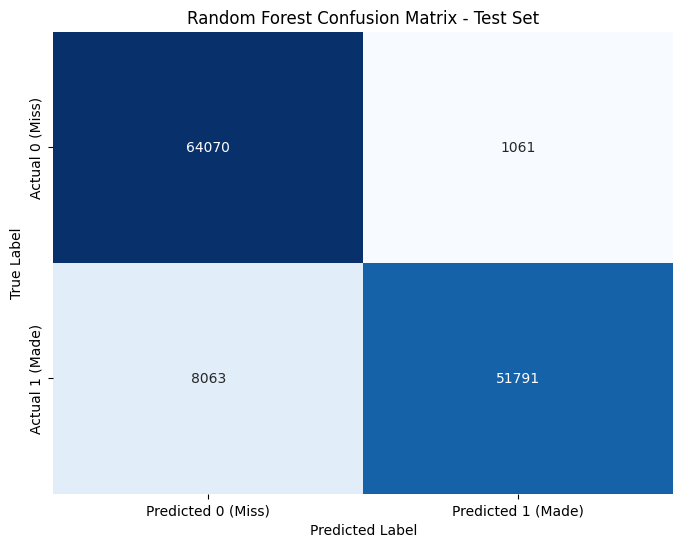


Random Forest Classification Report - Test Set:
              precision    recall  f1-score   support

 Shot Missed       0.89      0.98      0.93     65131
   Shot Made       0.98      0.87      0.92     59854

    accuracy                           0.93    124985
   macro avg       0.93      0.92      0.93    124985
weighted avg       0.93      0.93      0.93    124985



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

rf_test_preds = rf_model.predict(X_test)

cm_rf = confusion_matrix(y_test, rf_test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Miss)', 'Predicted 1 (Made)'],
            yticklabels=['Actual 0 (Miss)', 'Actual 1 (Made)'])
plt.title('Random Forest Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('\nRandom Forest Classification Report - Test Set:')
print(classification_report(y_test, rf_test_preds, target_names=['Shot Missed', 'Shot Made']))


### Random Forest Feature Importance

Let's analyze which features the Random Forest model considered most important for predicting shot accuracy.

Random Forest Feature Importances:


,Feature,Importance
9,score_diff,0.692388
1,seconds_remaining,0.076481
2,SHOT_DISTANCE,0.050291
4,LOC_Y,0.048630
3,LOC_X,0.042493
8,time_since_last_shot,0.037257
7,fg_pct_last_10,0.016805
0,QUARTER,0.011202
5,fg_pct_last_5,0.010850
6,fg_pct_last_3,0.007361


/tmp/ipykernel_3315/3983886627.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


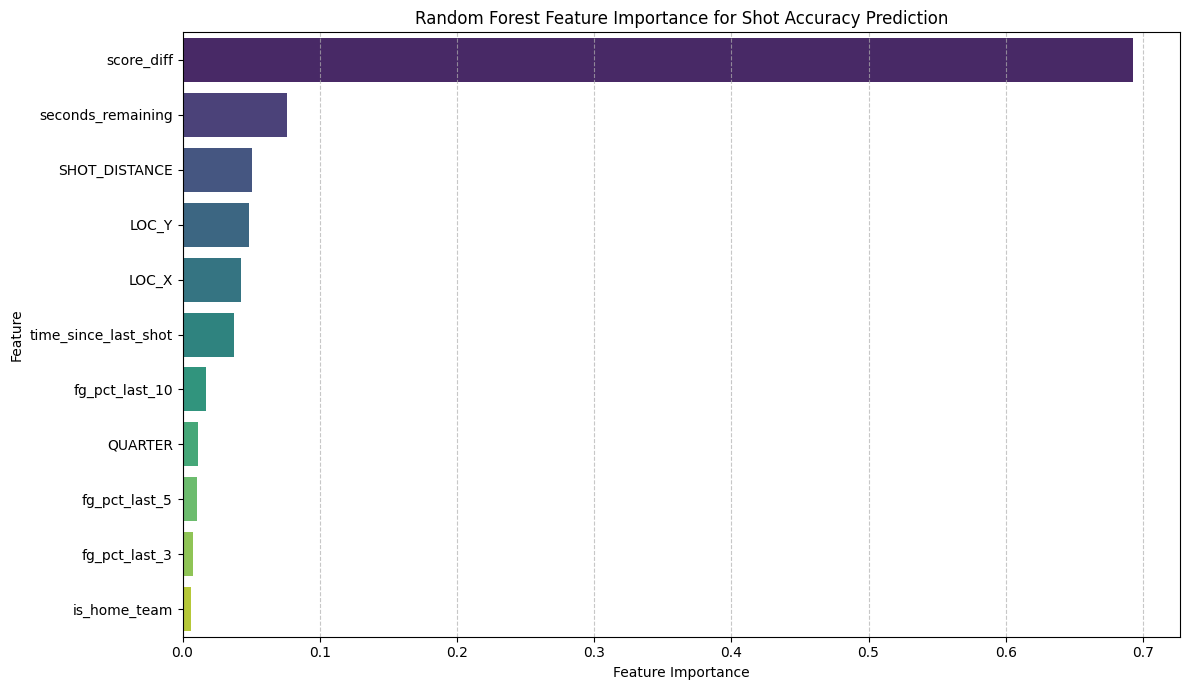

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_

feature_names = features


feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


print("Random Forest Feature Importances:")
display(feature_importance_df)


plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance for Shot Accuracy Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As you can see, the logistic regression and the SVM model both have test accuracies around 60% or lower. Both of these models are linear models. We may be able to infer that the relationship between the features in the datasets and the target variable is complex and non-linear, causing linear models to be relatively less successful at predicting shot accuracy.

Now, let's train another Random Forest model after removing some of the original features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


features_to_remove = ['fg_pct_last_5', 'fg_pct_last_10', 'fg_pct_last_3',
                      'time_since_last_shot', 'score_diff', 'is_home_team',
                      'seconds_remaining']

features_reduced = [f for f in ['QUARTER', 'seconds_remaining', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
            'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
            'time_since_last_shot', 'score_diff', 'is_home_team'] if f not in features_to_remove]

X_train_reduced = train_df[features_reduced]
X_val_reduced = val_df[features_reduced]
X_test_reduced = test_df[features_reduced]

target = 'SHOT_MADE'
y_train_rf = train_df[target]
y_val_rf = val_df[target]
y_test_rf = test_df[target]

rf_model_reduced = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

rf_model_reduced.fit(X_train_reduced, y_train_rf)

rf_train_acc_reduced = accuracy_score(y_train_rf, rf_model_reduced.predict(X_train_reduced))
rf_val_acc_reduced = accuracy_score(y_val_rf, rf_model_reduced.predict(X_val_reduced))
rf_test_acc_reduced = accuracy_score(y_test_rf, rf_model_reduced.predict(X_test_reduced))

print(f"Random Forest (Reduced Features) Training Accuracy:   {rf_train_acc_reduced:.4%}")
print(f"Random Forest (Reduced Features) Validation Accuracy: {rf_val_acc_reduced:.4%}")
print(f"Random Forest (Reduced Features) Test Accuracy:       {rf_test_acc_reduced:.4%}")

Random Forest (Reduced Features) Training Accuracy:   79.9771%
Random Forest (Reduced Features) Validation Accuracy: 58.8455%
Random Forest (Reduced Features) Test Accuracy:       58.4894%


As you can see, the test accuracy of the random forest model is much lower when we remove the momentum features that we added to the dataset.

We want to test out a **RNN model** to classify shot accuracy using our data. We want to use PyTorch to make this. Let's first use the validation dataset to test how long our sequence length should be. We will test between the hyperparameters of 3, 5, and 10.

### RNN Hyperparameter Tuning: Sequence Length

Let's evaluate the impact of different `SEQ_LENGTH` values on the RNN model's performance using the validation set. We will test `SEQ_LENGTH` values of 3, 5, and 10.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


def create_game_player_sequences(dataframe, feature_cols, target_col, seq_length):
    X_list, y_list = [], []
    for _, group in dataframe.groupby(['GAME_ID', 'PLAYER_ID']):
        if len(group) > seq_length:
            f_vals = group[feature_cols].values
            t_vals = group[target_col].values
            for i in range(seq_length, len(group)):
                X_list.append(f_vals[i-seq_length : i+1])
                y_list.append(t_vals[i])
    return np.array(X_list), np.array(y_list)

class MomentumLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(MomentumLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

def get_accuracy(model_to_eval, loader):
    model_to_eval.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_to_eval(inputs).squeeze()
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds)

SEQ_LENGTHS_TO_TEST = [3, 5, 10]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


validation_accuracies_rnn = {}
best_val_accuracy_rnn = -1
best_seq_length = None

for seq_len in SEQ_LENGTHS_TO_TEST:
    print(f"\n--- Testing SEQ_LENGTH = {seq_len} ---")

    df_tune = combined_df.copy()
    df_tune['prev_shot_made'] = df_tune.groupby(['GAME_ID', 'PLAYER_ID'])['SHOT_MADE'].shift(1).fillna(0).astype(int)

    features_for_rnn_tuning = ['SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'seconds_remaining', 'score_diff',
                               'prev_shot_made', 'time_since_last_shot', 'QUARTER', 'is_home_team']
    target_for_rnn_tuning = 'SHOT_MADE'

    n = len(df_tune)
    train_end_tune, val_end_tune = int(n * 0.60), int(n * 0.80)

    scaler_tune = StandardScaler()
    df_tune[features_for_rnn_tuning] = scaler_tune.fit_transform(df_tune[features_for_rnn_tuning])

    X_train_tune, y_train_tune = create_game_player_sequences(df_tune.iloc[:train_end_tune], features_for_rnn_tuning, target_for_rnn_tuning, seq_len)
    X_val_tune, y_val_tune = create_game_player_sequences(df_tune.iloc[train_end_tune:val_end_tune], features_for_rnn_tuning, target_for_rnn_tuning, seq_len)

    train_loader_tune = DataLoader(TensorDataset(torch.FloatTensor(X_train_tune), torch.FloatTensor(y_train_tune)), batch_size=128, shuffle=True)
    val_loader_tune = DataLoader(TensorDataset(torch.FloatTensor(X_val_tune), torch.FloatTensor(y_val_tune)), batch_size=128, shuffle=False)


    model_tune = MomentumLSTM(input_size=len(features_for_rnn_tuning), hidden_size=64, num_layers=2).to(device)
    criterion_tune = nn.BCELoss()
    optimizer_tune = torch.optim.Adam(model_tune.parameters(), lr=0.001)

    num_epochs_tune = 10
    for epoch in range(num_epochs_tune):
        model_tune.train()
        for inputs, labels in train_loader_tune:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_tune.zero_grad()
            outputs = model_tune(inputs).squeeze()
            loss = criterion_tune(outputs, labels)
            loss.backward()
            optimizer_tune.step()

    val_acc_curr = get_accuracy(model_tune, val_loader_tune)
    validation_accuracies_rnn[seq_len] = val_acc_curr
    print(f"Validation Accuracy for SEQ_LENGTH = {seq_len}: {val_acc_curr:.4%}")

    if val_acc_curr > best_val_accuracy_rnn:
        best_val_accuracy_rnn = val_acc_curr
        best_seq_length = seq_len

print(f"\n-------------------------------------------------------")
print(f"Optimal SEQ_LENGTH based on validation accuracy: {best_seq_length}")
print(f"Highest Validation Accuracy: {best_val_accuracy_rnn:.4%}")
print(f"-------------------------------------------------------")

Using device: cuda

--- Testing SEQ_LENGTH = 3 ---
Validation Accuracy for SEQ_LENGTH = 3: 92.0556%

--- Testing SEQ_LENGTH = 5 ---
Validation Accuracy for SEQ_LENGTH = 5: 92.1998%

--- Testing SEQ_LENGTH = 10 ---
Validation Accuracy for SEQ_LENGTH = 10: 90.1373%

-------------------------------------------------------
Optimal SEQ_LENGTH based on validation accuracy: 5
Highest Validation Accuracy: 92.1998%
-------------------------------------------------------


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


df = combined_df.copy()

df['prev_shot_made'] = df.groupby(['GAME_ID', 'PLAYER_ID'])['SHOT_MADE'].shift(1).fillna(0).astype(int)

features = ['SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'seconds_remaining', 'score_diff',
            'prev_shot_made', 'time_since_last_shot', 'QUARTER', 'is_home_team']
target = 'SHOT_MADE'

n = len(df)
train_end, val_end = int(n * 0.60), int(n * 0.80)

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

def create_game_player_sequences(dataframe, feature_cols, target_col, seq_length):
    X_list, y_list = [], []
    for _, group in dataframe.groupby(['GAME_ID', 'PLAYER_ID']):
        if len(group) > seq_length:
            f_vals = group[feature_cols].values
            t_vals = group[target_col].values
            for i in range(seq_length, len(group)):
                X_list.append(f_vals[i-seq_length : i+1])
                y_list.append(t_vals[i])
    return np.array(X_list), np.array(y_list)

SEQ_LENGTH = best_seq_length
X_train, y_train = create_game_player_sequences(df.iloc[:train_end], features, target, SEQ_LENGTH)
X_val, y_val = create_game_player_sequences(df.iloc[train_end:val_end], features, target, SEQ_LENGTH)
X_test, y_test = create_game_player_sequences(df.iloc[val_end:], features, target, SEQ_LENGTH)

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)), batch_size=128, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)), batch_size=128, shuffle=False)

class MomentumLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(MomentumLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MomentumLSTM(input_size=len(features), hidden_size=64, num_layers=2).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


def get_accuracy(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds)
print(f"RNN Training Accuracy:   {get_accuracy(train_loader):.4%}")
print(f"RNN Validation Accuracy: {get_accuracy(val_loader):.4%}")
print(f"RNN Test Accuracy:       {get_accuracy(test_loader):.4%}")

Using device: cuda
RNN Training Accuracy:   92.9857%
RNN Validation Accuracy: 92.3597%
RNN Test Accuracy:       92.2081%


### RNN Error Analysis: Confusion Matrix and Classification Report

To understand the types of errors the original RNN model is making, we can analyze its performance using a confusion matrix and a classification report on the test set. This will show us the number of true positives, true negatives, false positives, and false negatives.

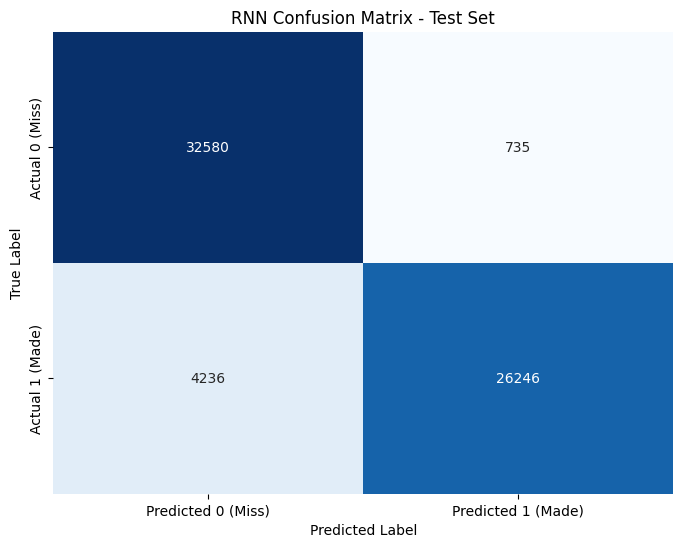


RNN Classification Report - Test Set:
              precision    recall  f1-score   support

 Shot Missed       0.88      0.98      0.93     33315
   Shot Made       0.97      0.86      0.91     30482

    accuracy                           0.92     63797
   macro avg       0.93      0.92      0.92     63797
weighted avg       0.93      0.92      0.92     63797



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def get_predictions_and_labels(loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

rnn_test_preds, rnn_test_labels = get_predictions_and_labels(test_loader)
cm = confusion_matrix(rnn_test_labels, rnn_test_preds)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Miss)', 'Predicted 1 (Made)'],
            yticklabels=['Actual 0 (Miss)', 'Actual 1 (Made)'])
plt.title('RNN Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print('\nRNN Classification Report - Test Set:')
print(classification_report(rnn_test_labels, rnn_test_preds, target_names=['Shot Missed', 'Shot Made']))


Now, let's train an RNN model with the same reduced set of features.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


df_rnn_reduced = combined_df.copy()

df_rnn_reduced['prev_shot_made'] = df_rnn_reduced.groupby(['GAME_ID', 'PLAYER_ID'])['SHOT_MADE'].shift(1).fillna(0).astype(int)


features_to_remove_rnn = ['fg_pct_last_5', 'fg_pct_last_10', 'fg_pct_last_3',
                          'time_since_last_shot', 'score_diff', 'is_home_team',
                          'seconds_remaining']

original_rnn_features = ['SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'seconds_remaining', 'score_diff',
                         'prev_shot_made', 'time_since_last_shot', 'QUARTER', 'is_home_team']

features_reduced_rnn = [f for f in original_rnn_features if f not in features_to_remove_rnn]

target_rnn = 'SHOT_MADE'


n = len(df_rnn_reduced)
train_end, val_end = int(n * 0.60), int(n * 0.80)


scaler_rnn_reduced = StandardScaler()
df_rnn_reduced[features_reduced_rnn] = scaler_rnn_reduced.fit_transform(df_rnn_reduced[features_reduced_rnn])

def create_game_player_sequences(dataframe, feature_cols, target_col, seq_length):
    X_list, y_list = [], []

    for _, group in dataframe.groupby(['GAME_ID', 'PLAYER_ID']):
        if len(group) > seq_length:
            f_vals = group[feature_cols].values
            t_vals = group[target_col].values
            for i in range(seq_length, len(group)):
                X_list.append(f_vals[i-seq_length : i+1])
                y_list.append(t_vals[i])
    return np.array(X_list), np.array(y_list)
SEQ_LENGTH = best_seq_length
X_train_rnn_reduced, y_train_rnn_reduced = create_game_player_sequences(df_rnn_reduced.iloc[:train_end], features_reduced_rnn, target_rnn, SEQ_LENGTH)
X_val_rnn_reduced, y_val_rnn_reduced = create_game_player_sequences(df_rnn_reduced.iloc[train_end:val_end], features_reduced_rnn, target_rnn, SEQ_LENGTH)
X_test_rnn_reduced, y_test_rnn_reduced = create_game_player_sequences(df_rnn_reduced.iloc[val_end:], features_reduced_rnn, target_rnn, SEQ_LENGTH)


train_loader_rnn_reduced = DataLoader(TensorDataset(torch.FloatTensor(X_train_rnn_reduced), torch.FloatTensor(y_train_rnn_reduced)), batch_size=128, shuffle=True)
val_loader_rnn_reduced = DataLoader(TensorDataset(torch.FloatTensor(X_val_rnn_reduced), torch.FloatTensor(y_val_rnn_reduced)), batch_size=128, shuffle=False)
test_loader_rnn_reduced = DataLoader(TensorDataset(torch.FloatTensor(X_test_rnn_reduced), torch.FloatTensor(y_test_rnn_reduced)), batch_size=128, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_rnn_reduced = MomentumLSTM(input_size=len(features_reduced_rnn), hidden_size=64, num_layers=2).to(device)
criterion_rnn_reduced = nn.BCELoss()
optimizer_rnn_reduced = torch.optim.Adam(model_rnn_reduced.parameters(), lr=0.001)


num_epochs = 10
for epoch in range(num_epochs):
    model_rnn_reduced.train()
    for inputs, labels in train_loader_rnn_reduced:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_rnn_reduced.zero_grad()
        outputs = model_rnn_reduced(inputs).squeeze()
        loss = criterion_rnn_reduced(outputs, labels)
        loss.backward()
        optimizer_rnn_reduced.step()

def get_accuracy_rnn_reduced(model_to_eval, loader):
    model_to_eval.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_to_eval(inputs).squeeze()
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds)

print(f"RNN (Reduced Features) Training Accuracy:   {get_accuracy_rnn_reduced(model_rnn_reduced, train_loader_rnn_reduced):.4%}")
print(f"RNN (Reduced Features) Validation Accuracy: {get_accuracy_rnn_reduced(model_rnn_reduced, val_loader_rnn_reduced):.4%}")
print(f"RNN (Reduced Features) Test Accuracy:       {get_accuracy_rnn_reduced(model_rnn_reduced, test_loader_rnn_reduced):.4%}")

Using device: cuda
RNN (Reduced Features) Training Accuracy:   62.6309%
RNN (Reduced Features) Validation Accuracy: 62.6882%
RNN (Reduced Features) Test Accuracy:       61.7333%


The large drop in test accuracy between the original RNN and the RNN with reduced features shows how important the momentum features are in predicting shot accuracy.

Now, let's test a **Linear Support Vector Classifier (LinearSVC)** to further investigate the performance of linear models. We will use feature scaling for this model.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

features = ['QUARTER', 'seconds_remaining', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
            'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
            'time_since_last_shot', 'score_diff', 'is_home_team']
target = 'SHOT_MADE'

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

scaler_lsvc = StandardScaler()
X_train_scaled_lsvc = scaler_lsvc.fit_transform(X_train)
X_val_scaled_lsvc = scaler_lsvc.transform(X_val)
X_test_scaled_lsvc = scaler_lsvc.transform(X_test)

lsvc_model = LinearSVC(random_state=42, dual=True, max_iter=20000)
print("Training LinearSVC model...")
lsvc_model.fit(X_train_scaled_lsvc, y_train)

lsvc_train_acc = accuracy_score(y_train, lsvc_model.predict(X_train_scaled_lsvc))
lsvc_val_acc = accuracy_score(y_val, lsvc_model.predict(X_val_scaled_lsvc))
lsvc_test_acc = accuracy_score(y_test, lsvc_model.predict(X_test_scaled_lsvc))

print(f"\nLinearSVC Training Accuracy:   {lsvc_train_acc:.4%}")
print(f"LinearSVC Validation Accuracy: {lsvc_val_acc:.4%}")
print(f"LinearSVC Test Accuracy:       {lsvc_test_acc:.4%}")

Training LinearSVC model...

LinearSVC Training Accuracy:   59.3354%
LinearSVC Validation Accuracy: 59.6864%
LinearSVC Test Accuracy:       59.3823%


Now, let's test a **Linear Support Vector Classifier (LinearSVC)** with a reduced set of features.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

features_to_remove = ['fg_pct_last_5', 'fg_pct_last_10', 'fg_pct_last_3',
                      'time_since_last_shot', 'score_diff', 'is_home_team',
                      'seconds_remaining']

original_lsvc_features = ['QUARTER', 'seconds_remaining', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
            'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
            'time_since_last_shot', 'score_diff', 'is_home_team']

features_reduced_lsvc = [f for f in original_lsvc_features if f not in features_to_remove]

target = 'SHOT_MADE'

X_train_reduced_lsvc, y_train_lsvc = train_df[features_reduced_lsvc], train_df[target]
X_val_reduced_lsvc, y_val_lsvc = val_df[features_reduced_lsvc], val_df[target]
X_test_reduced_lsvc, y_test_lsvc = test_df[features_reduced_lsvc], test_df[target]

scaler_lsvc_reduced = StandardScaler()
X_train_scaled_reduced_lsvc = scaler_lsvc_reduced.fit_transform(X_train_reduced_lsvc)
X_val_scaled_reduced_lsvc = scaler_lsvc_reduced.transform(X_val_reduced_lsvc)
X_test_scaled_reduced_lsvc = scaler_lsvc_reduced.transform(X_test_reduced_lsvc)

sample_fraction_lsvc = 0.1
sample_size_lsvc = int(len(X_train_scaled_reduced_lsvc) * sample_fraction_lsvc)
np.random.seed(42)
sampled_indices_lsvc = np.random.choice(len(X_train_scaled_reduced_lsvc), sample_size_lsvc, replace=False)

X_train_sampled_scaled_reduced_lsvc = X_train_scaled_reduced_lsvc[sampled_indices_lsvc]
y_train_sampled_lsvc = y_train_lsvc.iloc[sampled_indices_lsvc]

print(f"Original training data size: {len(X_train_scaled_reduced_lsvc)}")
print(f"Subsampled training data size: {len(X_train_sampled_scaled_reduced_lsvc)} ({sample_fraction_lsvc:.0%} of original)")
lsvc_model_reduced = LinearSVC(random_state=42, dual=True, max_iter=20000)
print("Training LinearSVC model with reduced features...")
lsvc_model_reduced.fit(X_train_sampled_scaled_reduced_lsvc, y_train_sampled_lsvc)

lsvc_train_acc_reduced = accuracy_score(y_train_lsvc, lsvc_model_reduced.predict(X_train_scaled_reduced_lsvc))
lsvc_val_acc_reduced = accuracy_score(y_val_lsvc, lsvc_model_reduced.predict(X_val_scaled_reduced_lsvc))
lsvc_test_acc_reduced = accuracy_score(y_test_lsvc, lsvc_model_reduced.predict(X_test_scaled_reduced_lsvc))

print(f"\nLinearSVC (Reduced Features) Training Accuracy:   {lsvc_train_acc_reduced:.4%}")
print(f"LinearSVC (Reduced Features) Validation Accuracy: {lsvc_val_acc_reduced:.4%}")
print(f"LinearSVC (Reduced Features) Test Accuracy:       {lsvc_test_acc_reduced:.4%}")

Original training data size: 374955
Subsampled training data size: 37495 (10% of original)
Training LinearSVC model with reduced features...

LinearSVC (Reduced Features) Training Accuracy:   59.9851%
LinearSVC (Reduced Features) Validation Accuracy: 60.5673%
LinearSVC (Reduced Features) Test Accuracy:       60.3128%
